# **Perancangan Gudang Data dan Analisis Multidimensi Performa Bisnis E-Commerce Olist Brazil Menggunakan Star Schema dan Atoti OLAP Cube**

Kelompok 11
1. Ruthtatia Grace Astridia (24031554072)
2. Bilqis Fadiyah Nisrina (24031554216)
3. Frelin Theresia Pania (24031554220)

# **Import Library & Data Acquisition**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/Shareddrives/UAS DataWarehouse'

customers = pd.read_csv('/content/drive/Shareddrives/UAS DataWarehouse/olist_customers_dataset.csv')
orders = pd.read_csv('/content/drive/Shareddrives/UAS DataWarehouse/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/drive/Shareddrives/UAS DataWarehouse/olist_order_items_dataset.csv')
products = pd.read_csv('/content/drive/Shareddrives/UAS DataWarehouse/olist_products_dataset.csv')
sellers = pd.read_csv('/content/drive/Shareddrives/UAS DataWarehouse/olist_sellers_dataset.csv')
payments = pd.read_csv('/content/drive/Shareddrives/UAS DataWarehouse/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/Shareddrives/UAS DataWarehouse/olist_order_reviews_dataset.csv')

print("Semua dataset berhasil dimuat.")

Semua dataset berhasil dimuat.


# **Data Profiling & Data Understanding**

In [4]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Products": products,
    "Sellers": sellers,
    "Payments": payments,
    "Reviews": reviews
}

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,99441,5,0,0
1,Orders,99441,8,4908,0
2,Order Items,112650,7,0,0
3,Products,32951,9,2448,0
4,Sellers,3095,4,0,0
5,Payments,103886,5,0,0
6,Reviews,99224,7,145903,0


In [5]:
for name, df in datasets.items():
    print(f"\n - {name}")

    df_types = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values
    })
    display(df_types)


 - Customers


,Column,Data Type
0,customer_id,object
1,customer_unique_id,object
2,customer_zip_code_prefix,int64
3,customer_city,object
4,customer_state,object



 - Orders


,Column,Data Type
0,order_id,object
1,customer_id,object
2,order_status,object
3,order_purchase_timestamp,object
4,order_approved_at,object
5,order_delivered_carrier_date,object
6,order_delivered_customer_date,object
7,order_estimated_delivery_date,object



 - Order Items


...

,Column,Data Type
0,seller_id,object
1,seller_zip_code_prefix,int64
2,seller_city,object
3,seller_state,object



 - Payments


,Column,Data Type
0,order_id,object
1,payment_sequential,int64
2,payment_type,object
3,payment_installments,int64
4,payment_value,float64



 - Reviews


,Column,Data Type
0,review_id,object
1,order_id,object
2,review_score,int64
3,review_comment_title,object
4,review_comment_message,object
5,review_creation_date,object
6,review_answer_timestamp,object


In [6]:
for name, df in datasets.items():
    print(f"\nMissing Value - {name}")

    # Membuat ringkasan missing value per dataset secara padat
    df_missing = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values
    })
    display(df_missing)


Missing Value - Customers


,Column,Missing Values
0,customer_id,0
1,customer_unique_id,0
2,customer_zip_code_prefix,0
3,customer_city,0
4,customer_state,0



Missing Value - Orders


,Column,Missing Values
0,order_id,0
1,customer_id,0
2,order_status,0
3,order_purchase_timestamp,0
4,order_approved_at,160
5,order_delivered_carrier_date,1783
6,order_delivered_customer_date,2965
7,order_estimated_delivery_date,0



Missing Value - Order Items


...

,Column,Missing Values
0,seller_id,0
1,seller_zip_code_prefix,0
2,seller_city,0
3,seller_state,0



Missing Value - Payments


,Column,Missing Values
0,order_id,0
1,payment_sequential,0
2,payment_type,0
3,payment_installments,0
4,payment_value,0



Missing Value - Reviews


,Column,Missing Values
0,review_id,0
1,order_id,0
2,review_score,0
3,review_comment_title,87656
4,review_comment_message,58247
5,review_creation_date,0
6,review_answer_timestamp,0


In [7]:
print("Sparsity Analysis (%)")

print("\nReviews")
print("review_comment_title :",
      round(reviews["review_comment_title"].isnull().mean()*100,2), "%")

print("review_comment_message :",
      round(reviews["review_comment_message"].isnull().mean()*100,2), "%")

print("\nProducts")
print("product_category_name :",
      round(products["product_category_name"].isnull().mean()*100,2), "%")

Sparsity Analysis (%)

Reviews
review_comment_title : 88.34 %
review_comment_message : 58.7 %

Products
product_category_name : 1.85 %


In [8]:
# Cek data duplikat pada ID Utama
print("Duplicate Order ID    :", orders["order_id"].duplicated().sum())
print("Duplicate Customer ID :", customers["customer_id"].duplicated().sum())

# Cek integritas relasi antar tabel (Orphaned Rows)
missing_customer = orders[~orders["customer_id"].isin(customers["customer_id"])]
print("Order tanpa customer  :", missing_customer.shape[0])

Duplicate Order ID    : 0
Duplicate Customer ID : 0
Order tanpa customer  : 0


# **Data Cleaning & Data Preparation**

In [9]:
# Kolom datetime pada tabel orders yang ingin dikonversi
cols_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in cols_orders:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date']   = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

print("Konversi datetime selesai.")

Konversi datetime selesai.


In [10]:
# Kolom numerik pada tabel products yang ingin diisi dengan nilai median
cols_numeric = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
]

for col in cols_numeric:
    products[col] = products[col].fillna(products[col].median())

print("Missing value numerik products berhasil ditangani.")

Missing value numerik products berhasil ditangani.


In [11]:
# Mengisi missing value pada kolom teks dengan nilai default
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No Title')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No Review')
products['product_category_name'] = products['product_category_name'].fillna('Unknown Category')

print("Missing value berhasil ditangani.")

Missing value berhasil ditangani.


In [12]:
print("Missing Value Setelah Cleaning \n")

print("Reviews")
display(reviews.isnull().sum())

print("\nProducts")
display(products.isnull().sum())

Missing Value Setelah Cleaning 

Reviews


,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,0
review_creation_date,0
review_answer_timestamp,0



Products


,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


# **Exploratory Data Analysis (EDA)**

Distribusi Review Score


,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


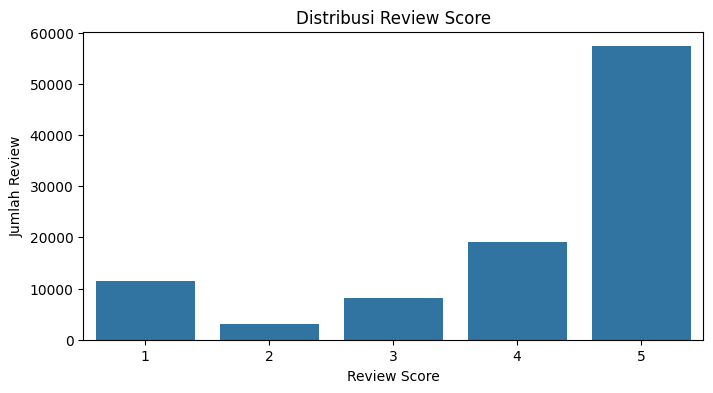

In [13]:
print("Distribusi Review Score")

review_dist = reviews["review_score"].value_counts().sort_index()

display(review_dist)

plt.figure(figsize=(8,4))
sns.countplot(data=reviews, x="review_score")

plt.title("Distribusi Review Score")
plt.xlabel("Review Score")
plt.ylabel("Jumlah Review")

plt.show()

In [14]:
print("Imbalance Ratio Review Score")

review_dist = reviews["review_score"].value_counts()

kelas_terbesar = review_dist.max()
kelas_terkecil = review_dist.min()

ratio = kelas_terbesar / kelas_terkecil

print("Kelas terbesar :", kelas_terbesar)
print("Kelas terkecil :", kelas_terkecil)
print("Imbalance Ratio :", round(ratio, 2))

Imbalance Ratio Review Score
Kelas terbesar : 57328
Kelas terkecil : 3151
Imbalance Ratio : 18.19


Statistik Payment Value


,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


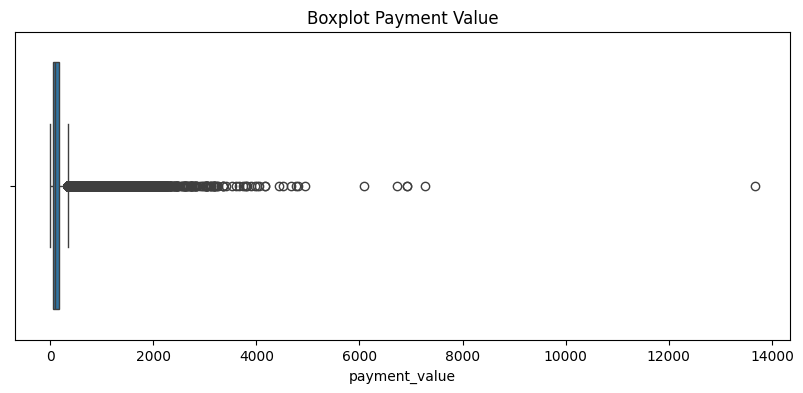

In [15]:
print("Statistik Payment Value")

display(payments["payment_value"].describe())

plt.figure(figsize=(10,4))

sns.boxplot(x=payments["payment_value"])

plt.title("Boxplot Payment Value")
plt.show()

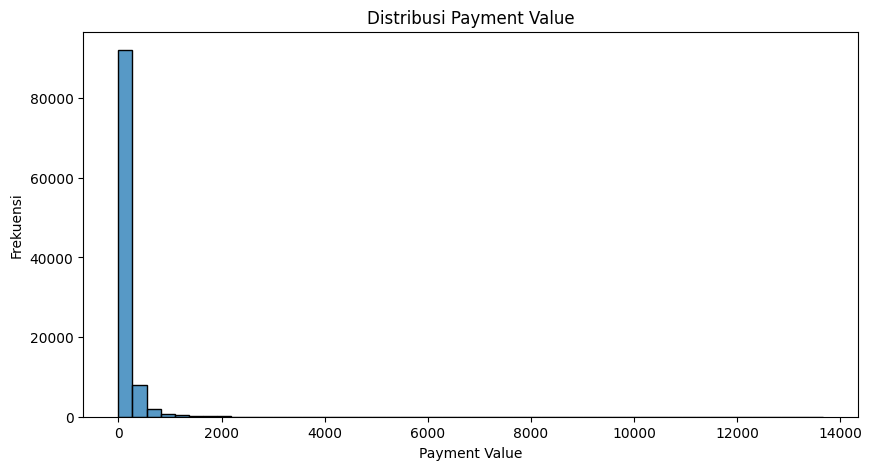

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(payments["payment_value"], bins=50)

plt.title("Distribusi Payment Value")
plt.xlabel("Payment Value")
plt.ylabel("Frekuensi")

plt.show()

# **Feature Engineering**

In [17]:
orders['year']    = orders['order_purchase_timestamp'].dt.year
orders['month']   = orders['order_purchase_timestamp'].dt.month
orders['day']     = orders['order_purchase_timestamp'].dt.day
orders['quarter'] = orders['order_purchase_timestamp'].dt.quarter

orders[['year', 'month', 'day', 'quarter']].head()

,year,month,day,quarter
0,2017,10,2,4
1,2018,7,24,3
2,2018,8,8,3
3,2017,11,18,4
4,2018,2,13,1


In [18]:
orders['date'] = orders['order_purchase_timestamp'].dt.date

print("Kolom date berhasil dibuat.")

Kolom date berhasil dibuat.


# **Data Integration & Star Schema Construction**

In [19]:
staging_data = (
    orders.merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(payments, on="order_id", how="left")
    .merge(reviews, on="order_id", how="left")
)

print("Integrasi data berhasil.")
print("Ukuran staging data :", staging_data.shape)
staging_data.head()

Integrasi data berhasil.
Ukuran staging data : (119143, 44)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Review,2018-08-18,2018-08-22 19:07:58


In [20]:
validation = pd.DataFrame({
    "Missing Values": staging_data.isnull().sum(),
    "Data Type": staging_data.dtypes
})

validation

,Missing Values,Data Type
order_id,0,object
customer_id,0,object
order_status,0,object
order_purchase_timestamp,0,datetime64[ns]
order_approved_at,177,datetime64[ns]
order_delivered_carrier_date,2086,datetime64[ns]
order_delivered_customer_date,3421,datetime64[ns]
order_estimated_delivery_date,0,datetime64[ns]
year,0,int32
month,0,int32


In [21]:
# Pembuatan Fact Sales
fact_sales = staging_data[
    [
        "order_id",
        "customer_id",
        "product_id",
        "seller_id",
        "payment_value",
        "review_score",
        "year",
        "month",
        "quarter",
        "date"
    ]
].copy()

fact_sales["payment_value"] = fact_sales["payment_value"].fillna(0)
fact_sales["review_score"] = fact_sales["review_score"].fillna(0)

fact_sales = fact_sales.drop_duplicates()

print("Tabel fact_sales berhasil dibuat.")
display(fact_sales.head())


print("\nVALIDASI AKHIR TABEL FAKTA")

print("Duplicate Fact Sales :", fact_sales.duplicated().sum())

fact_validation = pd.DataFrame({
    "Missing Values": fact_sales.isnull().sum(),
    "Data Type": fact_sales.dtypes
})

display(fact_validation)

Tabel fact_sales berhasil dibuat.


,order_id,customer_id,product_id,seller_id,payment_value,review_score,year,month,quarter,date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,18.12,4.0,2017,10,4,2017-10-02
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2.00,4.0,2017,10,4,2017-10-02
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,18.59,4.0,2017,10,4,2017-10-02
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,141.46,4.0,2018,7,3,2018-07-24
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,179.12,5.0,2018,8,3,2018-08-08



VALIDASI AKHIR TABEL FAKTA
Duplicate Fact Sales : 0


,Missing Values,Data Type
order_id,0,object
customer_id,0,object
product_id,812,object
seller_id,812,object
payment_value,0,float64
review_score,0,float64
year,0,int32
month,0,int32
quarter,0,int32
date,0,object


In [22]:
dim_customer = customers[["customer_id", "customer_city", "customer_state"]].drop_duplicates().copy()
print("\nTabel dim_customer berhasil dibuat.")
dim_customer.head()


Tabel dim_customer berhasil dibuat.


,customer_id,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,campinas,SP


In [23]:
dim_time = orders[
    [
        "date",
        "year",
        "month",
        "day",
        "quarter"
    ]
].drop_duplicates().copy()

print("Tabel dim_time berhasil dibuat.")
dim_time.head()

Tabel dim_time berhasil dibuat.


,date,year,month,day,quarter
0,2017-10-02,2017,10,2,4
1,2018-07-24,2018,7,24,3
2,2018-08-08,2018,8,8,3
3,2017-11-18,2017,11,18,4
4,2018-02-13,2018,2,13,1


In [24]:
dim_product = products.drop_duplicates().copy()
dim_seller = sellers.drop_duplicates().copy()

print("dim_product dan dim_seller berhasil disiapkan.")

dim_product dan dim_seller berhasil disiapkan.


# **Simulasi Periodic Load**

In [25]:
# Batch 1 : Tahun 2016 - 2017
fact_batch_1 = fact_sales[
    fact_sales['year'] <= 2017
]

# Batch 2 : Januari - April 2018
fact_batch_2 = fact_sales[
    (fact_sales['year'] == 2018) &
    (fact_sales['month'] <= 4)
]

# Batch 3 : Mei 2018 ke atas
fact_batch_3 = fact_sales[
    (fact_sales['year'] == 2018) &
    (fact_sales['month'] > 4)
]

print("\nfact_sales berhasil dibagi secara periodik:")
print("   - Batch 1:", fact_batch_1.shape)
print("   - Batch 2:", fact_batch_2.shape)
print("   - Batch 3:", fact_batch_3.shape)


fact_sales berhasil dibagi secara periodik:
   - Batch 1: (49536, 10)
   - Batch 2: (30234, 10)
   - Batch 3: (27677, 10)


# **Persiapan Data Analitik Seller**

In [26]:
# Menghitung total penjualan dan jumlah transaksi setiap seller
seller_performance = (
    order_items
    .groupby("seller_id")
    .agg(
        total_penjualan=("price", "sum"),
        total_transaksi=("order_id", "count")
    )
    .reset_index()
    .sort_values(by="total_penjualan", ascending=False)
)

print("Data seller performance berhasil dibuat.")
display(seller_performance.head())

Data seller performance berhasil dibuat.


,seller_id,total_penjualan,total_transaksi
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156
1013,53243585a1d6dc2643021fd1853d8905,222776.05,410
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1987
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364


In [27]:
# Menggabungkan data transaksi dan lokasi seller
seller_region = order_items.merge(
    sellers,
    on="seller_id",
    how="left"
)

print("Data seller dan wilayah berhasil digabungkan.")
display(seller_region.head())

Data seller dan wilayah berhasil digabungkan.


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [28]:
# Menghitung total penjualan dan jumlah seller per wilayah
seller_state = (
    seller_region
    .groupby("seller_state")
    .agg(
        total_penjualan=("price", "sum"),
        jumlah_seller=("seller_id", "nunique")
    )
    .reset_index()
    .sort_values(by="total_penjualan", ascending=False)
)

print("Data seller per wilayah berhasil dibuat.")
display(seller_state.head())

Data seller per wilayah berhasil dibuat.


,seller_state,total_penjualan,jumlah_seller
22,SP,8753396.21,1849
15,PR,1261887.21,349
8,MG,1011564.74,244
16,RJ,843984.22,171
20,SC,632426.07,190


# **Penyimpanan Hasil ETL ke File CSV**

In [29]:
path_clean = (
    path if path.endswith("/") else path + "/"
)

# Menyimpan tabel dimensi
dim_customer.to_csv(path_clean + "dim_customer.csv", index=False)
dim_product.to_csv(path_clean + "dim_product.csv", index=False)
dim_seller.to_csv(path_clean + "dim_seller.csv", index=False)
dim_time.to_csv(path_clean + "dim_time.csv", index=False)

# Menyimpan fact table
fact_sales.to_csv(path_clean + "fact_sales.csv", index=False)

# Menyimpan batch
fact_batch_1.to_csv(path_clean + "batch_1_sales.csv", index=False)
fact_batch_2.to_csv(path_clean + "batch_2_sales.csv", index=False)
fact_batch_3.to_csv(path_clean + "batch_3_sales.csv", index=False)

# Menyimpan data analitik seller
seller_performance.to_csv(path_clean + "seller_performance.csv", index=False)
seller_state.to_csv(path_clean + "seller_state.csv", index=False)

print("\nSEMUA PROSES BERHASIL!")
print("CSV siap digunakan untuk proses loading ke Supabase dan dashboard.")


SEMUA PROSES BERHASIL!
CSV siap digunakan untuk proses loading ke Supabase dan dashboard.


# **ETL Loading & Integrasi Database Supabase**

In [30]:
!pip install psycopg2-binary sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 54.1 MB/s eta 0:00:00


In [31]:
!pip install supabase

import pandas as pd
from supabase import create_client, Client

SUPABASE_URL = "https://uevtzmwkgqqmxaplfdrz.supabase.co"
SUPABASE_KEY = "sb_publishable_ZqXkxedBP_D5eE2g1DaZqQ_t-ETFbxr"

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
path = '/content/drive/Shareddrives/UAS DataWarehouse/'

def upload_to_supabase(table_name, file_csv):
    print(f"Sedang mengupload {table_name}...")
    try:
        df = pd.read_csv(path + file_csv)

        if table_name == 'dim_product':
            df = df[['product_id', 'product_category_name']]

        elif table_name == 'dim_seller':
            df = df[['seller_id', 'seller_city', 'seller_state']]

        df = df.where(pd.notnull(df), None)
        data_dict = df.to_dict(orient='records')

        for i in range(0, len(data_dict), 1000):
            batch = data_dict[i:i+1000]
            supabase.table(table_name).insert(batch).execute()
        print(f"--- Sukses mengupload {table_name}! ---\n")

    except Exception as e:
        if "23505" in str(e) or "already exists" in str(e):
            print(f"Catatan: Data {table_name} sudah ada di database.\n")
        else:
            print(f"Gagal di tabel {table_name}: {e}\n")

upload_to_supabase('dim_customer', 'dim_customer.csv')
upload_to_supabase('dim_product', 'dim_product.csv')
upload_to_supabase('dim_seller', 'dim_seller.csv')
upload_to_supabase('dim_time', 'dim_time.csv')

upload_to_supabase('fact_sales', 'batch_1_sales.csv')
upload_to_supabase('fact_sales', 'batch_2_sales.csv')
upload_to_supabase('fact_sales', 'batch_3_sales.csv')

upload_to_supabase('seller_performance', 'seller_performance.csv')
upload_to_supabase('seller_state_analytics', 'seller_state.csv')

print("SELURUH PROSES MIGRASI DAN SINKRONISASI DATABASES SUKSES!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.7 MB/s eta 0:00:00
Sedang mengupload dim_customer...
Catatan: Data dim_customer sudah ada di database.

Sedang mengupload dim_product...
Catatan: Data dim_product sudah ada di database.

Sedang mengupload dim_seller...
Catatan: Data dim_seller sudah ada di database.

Sedang mengupload dim_time...
Catatan: Data dim_time sudah ada di database.

Sedang mengupload fact_sales...
--- Sukses mengupload fact_sales! ---

Sedang mengupload fact_sales...
--- Sukses mengupload fact_sales! ---

Sedang mengupload fact_sales...
--- Sukses mengupload fact_sales! ---

Sedang mengupload seller_performance...
Catatan: Data seller_performance sudah ada di database.

Sedang mengupload seller_state_analytics...
Catatan: Data seller_state_analytics sudah ada di database.

SELURUH PROSES MIGRASI DAN SINKRONISASI DATABASES SUKSES!


In [32]:
import os
import pandas as pd

path = '/content/drive/Shareddrives/UAS DataWarehouse/'
files = [f for f in os.listdir(path) if f.endswith('.csv')]

print("STRUKTUR KOLOM DATASET DI GOOGLE DRIVE\n")

for file_csv in files:
    try:
        # Membaca hanya 1 baris pertama saja agar prosesnya instan dan hemat memori
        df = pd.read_csv(path + file_csv, nrows=1)
        print(f"Nama File: {file_csv}")
        print(f"Daftar Kolom: {list(df.columns)}")
    except Exception as e:
        print(f"Gagal membaca file {file_csv}: {e}")

STRUKTUR KOLOM DATASET DI GOOGLE DRIVE

Nama File: olist_customers_dataset.csv
Daftar Kolom: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Nama File: olist_order_items_dataset.csv
Daftar Kolom: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Nama File: olist_order_payments_dataset.csv
Daftar Kolom: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
Nama File: olist_order_reviews_dataset.csv
Daftar Kolom: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
Nama File: olist_orders_dataset.csv
Daftar Kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Nama File: olist_products_dataset.csv
Daftar Kolom: ['

In [2]:
import os
import pandas as pd
import atoti as tt
from supabase import create_client, Client

# 1. SETTING JALUR JAVA
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.11.9-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

# 2. KONEKSI SUPABASE
SUPABASE_URL = "https://uevtzmwkgqqmxaplfdrz.supabase.co"
SUPABASE_KEY = "sb_publishable_ZqXkxedBP_D5eE2g1DaZqQ_t-ETFbxr"

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

# 3. PROSES DATA PRESENTATION
print("Memulai penarikan data dari Cloud Supabase...")

try:
    # A. Menarik data dari tabel fakta utama
    response = supabase.table("fact_sales").select("*").execute()
    df_sales = pd.DataFrame(response.data)
    print(f"Sukses Menarik Data Fact Sales! Jumlah baris: {len(df_sales)}")

    # B. Menarik data performa seller
    response_perf = supabase.table("seller_performance").select("*").execute()
    df_seller_perf = pd.DataFrame(response_perf.data)
    print(f"Sukses Menarik Data Seller Performance! Jumlah baris: {len(df_seller_perf)}")

    # C. Menarik data analisis wilayah
    response_state = supabase.table("seller_state_analytics").select("*").execute()
    df_seller_state = pd.DataFrame(response_state.data)
    print(f"Sukses Menarik Data Seller State Analytics! Jumlah baris: {len(df_seller_state)}")

    # SINKRONISASI TIPE DATA
    df_sales["seller_id"] = df_sales["seller_id"].astype(str)
    df_seller_perf["seller_id"] = df_seller_perf["seller_id"].astype(str)

    # Hubungkan kolom wilayah ke tabel fakta agar ada jembatan data teksnya
    if "seller_state" not in df_sales.columns:
        if "seller_state" in df_seller_perf.columns:
            peta_wilayah = df_seller_perf[["seller_id", "seller_state"]].drop_duplicates()
            df_sales = pd.merge(df_sales, peta_wilayah, on="seller_id", how="left")
        else:
            df_sales["seller_state"] = "SP"

    df_sales["seller_state"] = df_sales["seller_state"].fillna("SP").astype(str)
    df_seller_state["seller_state"] = df_seller_state["seller_state"].astype(str)

    # 4. MEMBUAT CUBE OLAP ATOTI
    print("\nMenyalakan Mesin OLAP Atoti")

    konfigurasi = tt.SessionConfig(
        port=9099,
        user_content_storage="./atoti_v2"
    )

    session = tt.Session.start(konfigurasi)

    # Memasukkan data ke tabel Atoti
    tabel_olap = session.read_pandas(df_sales, keys=["order_id"], table_name="Sales_Fact")
    tabel_perf_olap = session.read_pandas(df_seller_perf, keys=["seller_id"], table_name="Seller_Performance")
    tabel_state_olap = session.read_pandas(df_seller_state, keys=["seller_state"], table_name="Seller_State_Analytics")

    # Gabungkan tabel di level OLAP
    tabel_olap.join(tabel_perf_olap)
    tabel_olap.join(tabel_state_olap)

    # Membuat Cube OLAP dengan mode otomatis
    cube = session.create_cube(tabel_olap, mode="auto")

    cube.measures["total_transaksi.SUM"] = tt.agg.sum(tabel_perf_olap["total_transaksi"])
    cube.measures["total_penjualan.SUM"] = tt.agg.sum(tabel_perf_olap["total_penjualan"])
    cube.hierarchies["seller_state"] = [tabel_olap["seller_state"]]

    print("\nATOTI BERHASIL DINYALAKAN MURNI")
    print(f"Link dashboard kamu: {session.url}")

except Exception as e:
    print(f"\nAda kendala saat eksekusi: {e}")

Welcome to Atoti 0.9.14!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.
Memulai penarikan data dari Cloud Supabase...
Sukses Menarik Data Fact Sales! Jumlah baris: 1000
Sukses Menarik Data Seller Performance! Jumlah baris: 1000
Sukses Menarik Data Seller State Analytics! Jumlah baris: 23

Menyalakan Mesin OLAP Atoti

ATOTI BERHASIL DINYALAKAN MURNI
Link dashboard kamu: http://localhost:9099


In [3]:
session.close()
print("mesin Atoti mati")

mesin Atoti mati
